In [15]:
# Import libraries for data analysis, numerical computing, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Load the Telco customer churn dataset from an Excel file into a DataFrame
df=pd.read_excel("Telco_customer_churn.xlsx")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [17]:
# Display the dataset shape: number of rows and columns
df.shape

(7043, 33)

In [18]:
# Show dataset information such as data types and missing value counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [19]:
# Count the number of customers in each churn category
df['Churn Label'].value_counts()


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

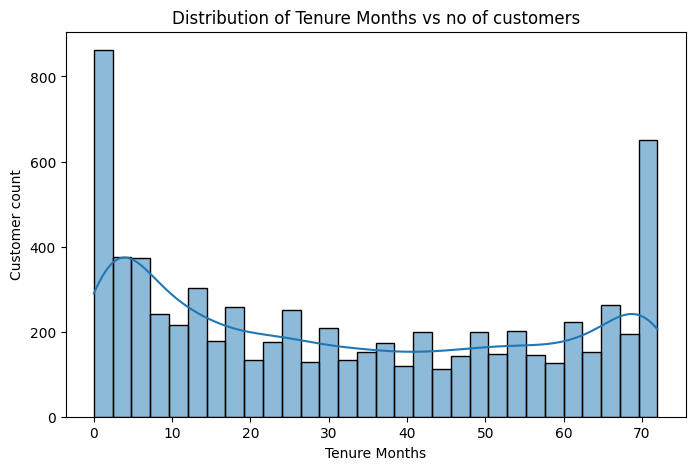

In [20]:
# Plot the distribution of customer tenure in months
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customers')
plt.show()

In [21]:
# Find the longest customer tenure in months
df['Tenure Months'].max()

np.int64(72)

In [22]:
# Find the shortest customer tenure in months
df['Tenure Months'].min()

np.int64(0)

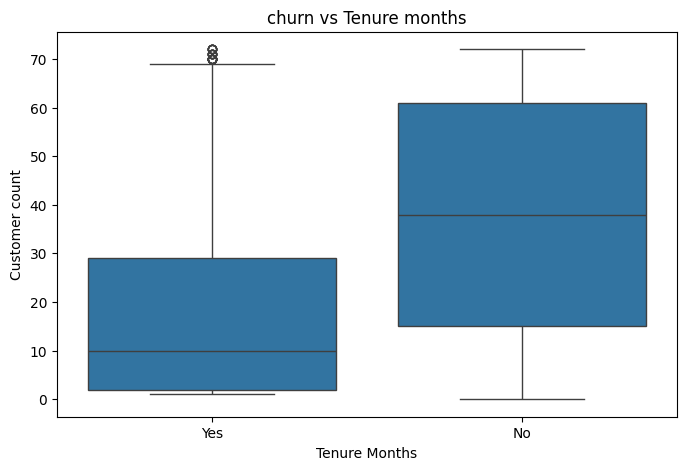

In [23]:
# Create a boxplot showing tenure by churn label to compare distributions
plt.figure(figsize=(8,5))
sns.boxplot(y='Tenure Months', x='Churn Label', data=df)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('churn vs Tenure months')
plt.show()

In [24]:
# List the unique churn labels present in the dataset
df['Churn Label'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

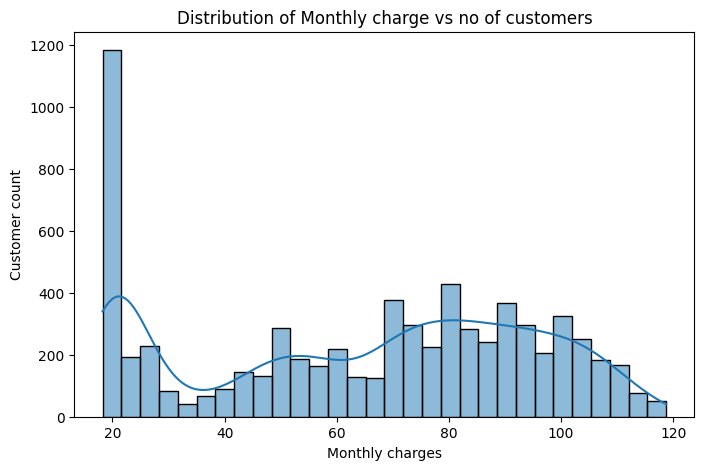

In [25]:
# Plot the distribution of monthly charges for all customers
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('Monthly charges')
plt.ylabel('Customer count')
plt.title('Distribution of Monthly charge vs no of customers')
plt.show()

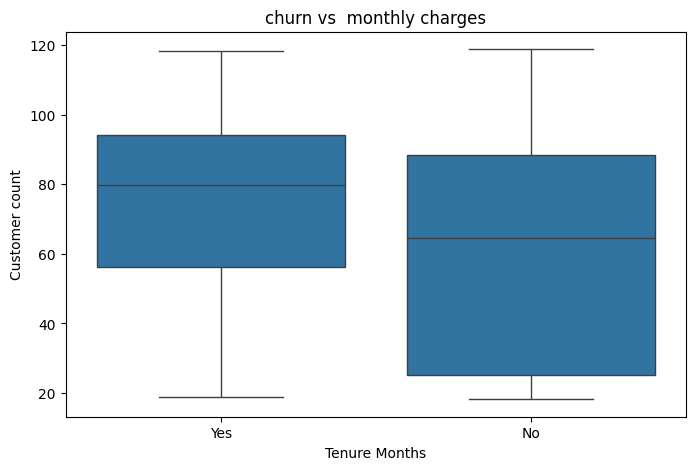

In [26]:
# Compare monthly charges distribution for churned vs retained customers
plt.figure(figsize=(8,5))
sns.boxplot(y='Monthly Charges', x='Churn Label', data=df)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('churn vs  monthly charges')
plt.show()

In [27]:
# Calculate the 25th, 50th, and 75th percentiles of monthly charges for churned customers
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25, 0.5, 0.75])

0.25    56.15
0.50    79.65
0.75    94.20
Name: Monthly Charges, dtype: float64

In [28]:
# Calculate the 25th, 50th, and 75th percentiles of monthly charges for non-churned customers
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25, 0.5, 0.75])

0.25    25.100
0.50    64.425
0.75    88.400
Name: Monthly Charges, dtype: float64

In [29]:
# Generate summary statistics for the Monthly Charges column
df['Monthly Charges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charges, dtype: float64

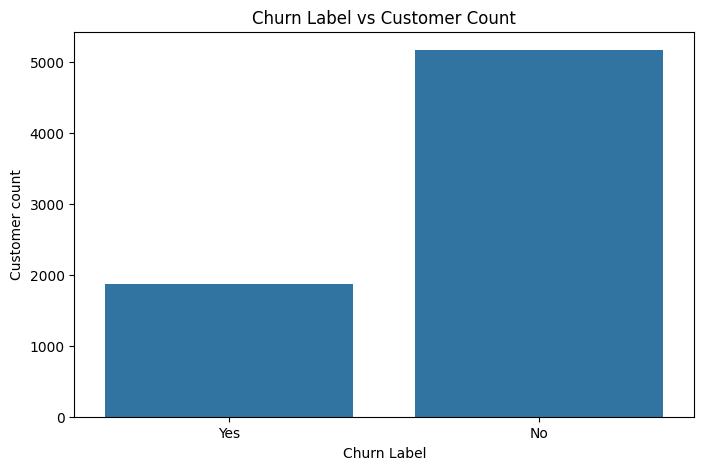

In [30]:
# Plot the number of customers by churn label
plt.figure(figsize=(8,5))
sns.countplot(x='Churn Label', data=df)
plt.xlabel('Churn Label')
plt.ylabel('Customer count')
plt.title('Churn Label vs Customer Count')
plt.show()

In [31]:
# Show the distinct contract types available in the dataset
df['Contract'].unique()

<StringArray>
['Month-to-month', 'Two year', 'One year']
Length: 3, dtype: str

In [32]:
# Count customers for each contract type
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

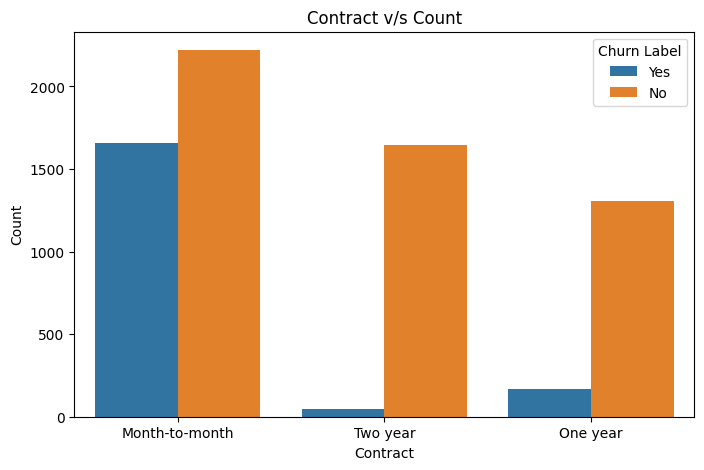

In [33]:
# Plot customer counts for each contract type, colored by churn status
plt.figure( figsize = (8, 5) ) #height and width
sns.countplot( x = 'Contract', hue = 'Churn Label', data = df)
plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Contract v/s Count')
plt.show()

In [34]:
# Re-check the dataset structure and data types after initial inspection
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [35]:
# List the unique internet service types used by customers
df['Internet Service'].unique()

<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

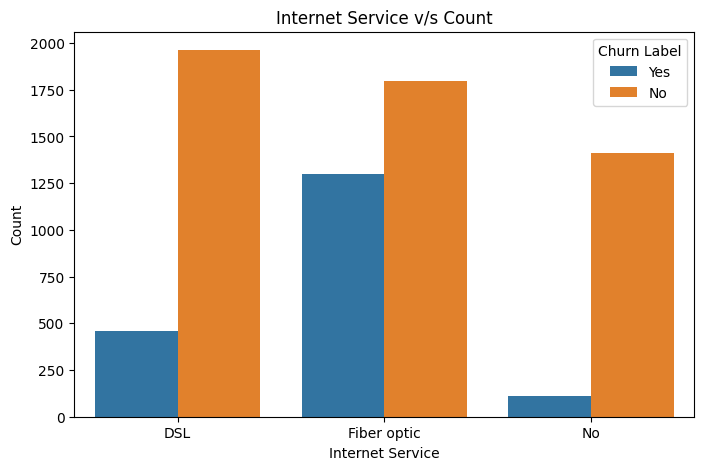

In [36]:
# Plot internet service type counts and compare churn rates for each type
plt.figure( figsize = (8, 5) ) #height and width
sns.countplot( x = 'Internet Service', hue = 'Churn Label', data = df)
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.title('Internet Service v/s Count')
plt.show()

In [37]:
# List the unique payment methods used by customers
df['Payment Method'].unique()

<StringArray>
[             'Mailed check',          'Electronic check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [38]:
# Count customers for each payment method
df['Payment Method'].value_counts()

Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

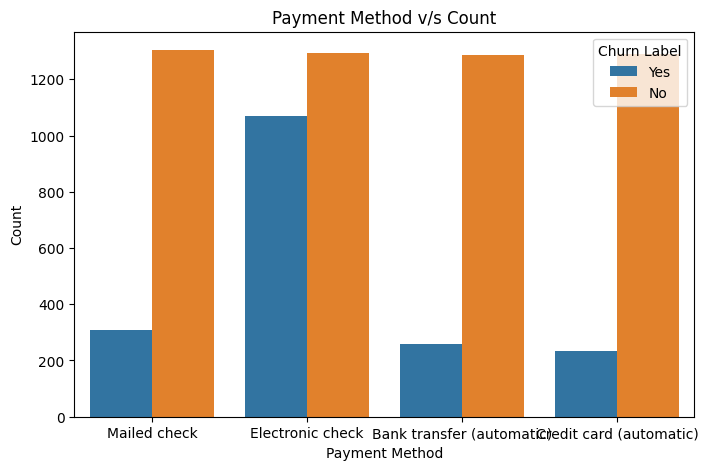

In [39]:
# Plot payment method counts and compare churn outcomes by method
plt.figure( figsize = (8, 5) ) #height and width
sns.countplot( x = 'Payment Method', hue = 'Churn Label', data = df)
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Payment Method v/s Count')
plt.show()

In [40]:
# List the unique tech support options available to customers
df['Tech Support'].unique()

<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [41]:
# Count customers by tech support subscription type
df['Tech Support'].value_counts()

Tech Support
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

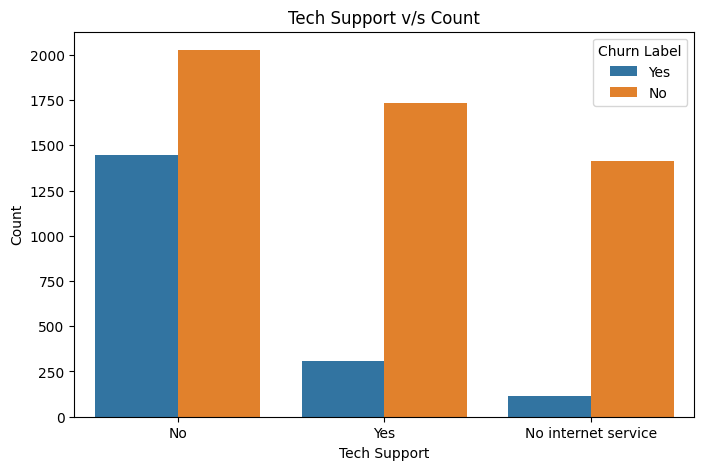

In [42]:
# Plot tech support counts and compare churn rates for each support option
plt.figure( figsize = (8, 5) ) #height and width
sns.countplot( x = 'Tech Support', hue = 'Churn Label', data = df)
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.title('Tech Support v/s Count')
plt.show()

In [43]:
# Compute the average tenure for churned and non-churned customers
avg_tenure=df.groupby("Churn Label")['Tenure Months'].mean()

In [44]:
# Display the average tenure values by churn label
avg_tenure

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

In [45]:
# Verify the dataset structure again after any transformations
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [46]:
# Define numerical columns for correlation analysis
numerical_cols=['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']

In [47]:
# Calculate the correlation matrix for the selected numerical columns
correlation_matrix=df[numerical_cols].corr()

In [48]:
# Display the correlation matrix results
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [49]:
# Import normalization helper and compute churn rates by contract type
from matplotlib.colors import Normalize
contract_churn=pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [50]:
# Display the Total Charges column values for inspection
df['Total Charges']

0        108.15
1        151.65
2         820.5
3       3046.05
4        5036.3
         ...   
7038     1419.4
7039     1990.5
7040     7362.9
7041     346.45
7042     6844.5
Name: Total Charges, Length: 7043, dtype: object

In [51]:
# Convert Total Charges to numeric and re-display the column
df['Total Charges']=pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges']

0        108.15
1        151.65
2        820.50
3       3046.05
4       5036.30
         ...   
7038    1419.40
7039    1990.50
7040    7362.90
7041     346.45
7042    6844.50
Name: Total Charges, Length: 7043, dtype: float64